# Is Beta a Number, or a Regime?

### Estimating market beta by linear regression — and finding out it doesn't hold still

**Author:** Krish P. · Independent project, mentored by Justin Rowland (Data Analytics
Instructor, Wake Tech) · *Version 2*

---

## The question

A stock's **beta** is the single number finance uses to say how much it moves when the
market moves. It comes from a linear regression of the stock's returns on the market's
returns — literally `y = mx + b`, where the slope `m` *is* beta.

Version 1 of this project estimated Apple's beta on two years of daily data, got **1.09**,
and then did something I didn't plan: it **failed out-of-sample**. Fit on the first 80% of
days, tested on the last 20%, the R² came out **negative** — the fitted line predicted the
recent period *worse than guessing the average return*. Refitting on the test window alone
gave a beta of 0.32 instead of 1.18.

That could be two things:

1. **Noise.** 100 test days is not many; betas wobble.
2. **A real change** in how Apple relates to the market.

Version 1 could not tell those apart, because `sklearn`'s `LinearRegression` gives you a
number and no measure of uncertainty around it. This version answers it properly.

## What this notebook does

| § | Question |
|---|---|
| 1 | Get the data, and build *excess* returns the way CAPM actually specifies |
| 2 | Estimate beta **with** standard errors, confidence intervals and hypothesis tests |
| 3 | Check whether the regression's assumptions actually hold — and fix what doesn't |
| 4 | Decompose Apple's risk into the part the market explains and the part it doesn't |
| 5 | **Test formally whether beta changed** (Chow test, then a scan for *when*) |
| 6 | Watch beta move through time |
| 7 | Ask whether this is an Apple story or a whole-market story — and find the mechanism |
| 8 | Try to break the finding (outliers, arbitrary split dates, historical context) |
| 9 | So *which* beta should you actually quote? |
| 10 | What I'd claim, and what I wouldn't |

> **A note on reproducibility.** Data is pulled live from Yahoo Finance, so re-running this
> later shifts every number slightly as new days arrive. The dates and figures in the
> commentary are from the run committed with this notebook.

In [1]:
# --- Libraries -------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import statsmodels.api as sm                      # regression WITH inference (SEs, t, p)
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.tsa.stattools import acf
from scipy import stats

# --- Plot style ------------------------------------------------------------
# One palette for the whole notebook, checked for colour-blind separation.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "legend.frameon": False, "figure.dpi": 120, "savefig.bbox": "tight",
})
pd.set_option("display.width", 160)
print("ready")

ready


---
## 1. The data

**Eleven stocks plus two market benchmarks, five years of daily prices.**

Version 1 used one stock and two years. Both are widened here for specific reasons:

- **Five years, not two** — a structural break needs history on both sides of it to be
  visible at all, and rolling estimates need room to roll.
- **Eleven stocks, not one** — this turns out to be the single most important design
  decision in the notebook. With one stock I can only say "Apple's beta changed." With
  eleven I can ask *"did everyone's?"*, which is a completely different question and the
  one that actually has an interesting answer.

The stocks are picked to span the beta spectrum on purpose: high-beta growth (NVDA, TSLA),
mega-cap tech (AAPL, MSFT), cyclicals (JPM, XOM), and defensives (KO, PG, JNJ, WMT, NEE).

**Two benchmarks:**
- `SPY` — S&P 500, **cap-weighted**: bigger companies count more.
- `RSP` — the same 500 companies, **equal-weighted**: every company counts the same.

Carrying both costs one extra ticker and buys a control experiment in §7.

In [2]:
STOCKS     = ["AAPL", "MSFT", "NVDA", "TSLA", "JPM", "XOM", "WMT", "KO", "PG", "JNJ", "NEE"]
BENCHMARKS = ["SPY", "RSP"]
FOCUS      = "AAPL"     # the stock version 1 was about
MARKET     = "SPY"      # the default benchmark

prices = yf.download(STOCKS + BENCHMARKS, period="5y", auto_adjust=True, progress=False)["Close"]

print(f"{prices.shape[0]} trading days x {prices.shape[1]} tickers")
print(f"{prices.index.min().date()}  ->  {prices.index.max().date()}")
print(f"missing values: {int(prices.isna().sum().sum())}")
prices.tail(3).round(2)

1255 trading days x 13 tickers
2021-09-13  ->  2026-09-11
missing values: 0


Ticker,AAPL,JNJ,JPM,KO,MSFT,NEE,NVDA,PG,RSP,SPY,TSLA,WMT,XOM
Date,,,,,,,,,,,,,
2026-09-09,315.34,267.08,354.71,87.55,491.65,82.65,223.42,142.64,214.64,762.40,367.81,105.83,164.23
2026-09-10,326.57,266.35,353.56,87.83,492.44,82.44,218.36,142.97,213.17,757.83,363.56,105.73,165.23
2026-09-11,332.27,265.58,356.23,88.29,495.63,82.31,218.29,145.27,214.87,764.29,365.44,107.15,165.99


`auto_adjust=True` matters more than it looks. It restates history for stock splits and
dividends. Without it, a 4-for-1 split shows up as a single day where the price falls 75% —
and the regression would read that as a catastrophic return unrelated to the market,
silently poisoning the estimate. This one flag is the difference between a correct beta and
a meaningless one.

### Returns, not prices

Regressing tomorrow's *price* on today's *price* produces an R² near 0.99 and means nothing:
Apple at \$325 today will be near \$325 tomorrow, so a slope of ~1 looks brilliant while
having learned nothing. Prices are close to a random walk. **Returns** — percentage change
day over day — remove the price level and leave only the movement, which is the thing that
actually varies. This is why beta is universally defined on returns.

### Excess returns: doing CAPM properly

Version 1 regressed raw returns. The Capital Asset Pricing Model is actually specified on
**excess** returns — returns above the risk-free rate, i.e. above what you could earn
holding Treasury bills instead:

$$ (r_{\text{stock}} - r_f) \;=\; \alpha \;+\; \beta\,(r_{\text{market}} - r_f) \;+\; \varepsilon $$

`^IRX` is the 13-week Treasury bill yield, quoted as an annualised percent, so it gets
converted to a daily rate by de-annualising over 252 trading days.

In [3]:
irx = yf.download("^IRX", period="5y", auto_adjust=True, progress=False)["Close"]["^IRX"]

returns  = prices.pct_change().dropna()
rf_daily = ((1 + irx / 100) ** (1 / 252) - 1).reindex(returns.index).ffill()
excess   = returns.sub(rf_daily, axis=0)

print(f"risk-free rate over the sample: {rf_daily.min()*252*100:.2f}% to {rf_daily.max()*252*100:.2f}% annualised")
print(f"excess return matrix: {excess.shape[0]} days x {excess.shape[1]} tickers")
excess[[FOCUS, MARKET, "RSP"]].tail(3).round(5)

risk-free rate over the sample: 0.02% to 5.21% annualised
excess return matrix: 1254 days x 13 tickers


Ticker,AAPL,SPY,RSP
Date,,,
2026-09-09,-0.00293,-0.00480,-0.00979
2026-09-10,0.03546,-0.00614,-0.00700
2026-09-11,0.01730,0.00837,0.00782


### Does subtracting the risk-free rate actually change anything?

Worth checking rather than assuming — this is the kind of step that's easy to perform as
ritual without knowing what it buys.

In [4]:
def fit(y, x):
    """Ordinary least squares of y on x, with an intercept. Returns a statsmodels result."""
    return sm.OLS(y, sm.add_constant(x)).fit()

raw_fit = fit(returns[FOCUS], returns[MARKET])
exc_fit = fit(excess[FOCUS],  excess[MARKET])

comparison = pd.DataFrame({
    "beta":            [raw_fit.params.iloc[1], exc_fit.params.iloc[1]],
    "alpha (daily)":   [raw_fit.params.iloc[0], exc_fit.params.iloc[0]],
    "alpha (annual %)":[((1 + raw_fit.params.iloc[0]) ** 252 - 1) * 100,
                        ((1 + exc_fit.params.iloc[0]) ** 252 - 1) * 100],
}, index=["raw returns", "excess returns"])
print(comparison.round(4).to_string())
print(f"\nbeta moved by {abs(raw_fit.params.iloc[1] - exc_fit.params.iloc[1]):.5f}  -- negligible")
print(f"alpha moved by {comparison['alpha (annual %)'].diff().iloc[-1]:+.2f} percentage points per year -- not negligible")

                  beta  alpha (daily)  alpha (annual %)
raw returns     1.1715         0.0002            4.6004
excess returns  1.1717         0.0002            5.2526

beta moved by 0.00019  -- negligible
alpha moved by +0.65 percentage points per year -- not negligible


**The answer: it barely touches beta, but it materially changes alpha.**

That makes sense mechanically. Beta is a *slope*, and the risk-free rate is nearly constant
from one day to the next — subtracting a near-constant from both sides shifts the cloud of
points but doesn't tilt it. Alpha is an *intercept*, so a level shift lands on it directly.

So: if you only care about beta, the risk-free rate is optional. The moment you want to say
anything about alpha — which is supposed to mean "return earned beyond what market exposure
explains" — it is required. Version 1 reported an alpha it wasn't entitled to call alpha.

---
## 2. The regression, with the uncertainty attached

Version 1 used `sklearn.LinearRegression`, which returns a slope and nothing else. That is
fine for prediction and useless for inference: it can't tell you whether a beta of 1.18 is
meaningfully different from 1.0, or from 0.32.

`statsmodels` fits the identical line — same ordinary least squares, same arithmetic — but
reports the **standard error** of each coefficient, which is what every question in this
notebook actually depends on.

In [5]:
y = excess[FOCUS]
X = excess[[MARKET]]
model = fit(y, X)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.516
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     1333.
Date:                Sun, 13 Sep 2026   Prob (F-statistic):          2.43e-199
Time:                        23:47:51   Log-Likelihood:                 3735.5
No. Observations:                1254   AIC:                            -7467.
Df Residuals:                    1252   BIC:                            -7457.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.584      0.5

### Reading this table

Everything below refers to the `SPY` row, which is beta.

**`coef` — the slope, ≈ 1.17.** On a day the market returns +1% above cash, Apple is
predicted to return about +1.17% above cash. Above 1 means it amplifies market moves;
below 1 means it damps them.

**`std err` — the standard error, ≈ 0.03.** This is the new thing, and the point of
switching libraries. It's the estimated standard deviation of the slope estimate itself:
*if I re-ran this on a different five-year sample from the same underlying process, how
much would the slope bounce around?* Small SE = the data pins the slope down tightly.

**`t` — the t-statistic = coef / std err.** How many standard errors the estimate sits
from zero. At ~36 it is enormous, but that is testing a question nobody asked: "is Apple
related to the market **at all**?" Of course it is.

**`P>|t|` — the p-value.** Probability of seeing an estimate this extreme if the true value
were zero. Effectively 0 here.

**`[0.025  0.975]` — the 95% confidence interval.** The range of betas consistent with this
data. This is the honest way to report a beta: not "1.17" but "1.17, and the data is
consistent with anywhere in roughly [1.11, 1.24]."

**`R-squared` ≈ 0.52.** The fraction of Apple's daily variation that market moves account
for. Half. §4 gives this a much more concrete meaning than "goodness of fit."

Note also the **`const` row**: alpha is ~0.0002/day with a p-value around 0.56. It is
**not statistically distinguishable from zero**. That is the correct and unglamorous
finding — Apple did not deliver reliable risk-adjusted outperformance over this window.

### The test that actually matters: is beta different from 1?

A beta of exactly 1 means "moves with the market, one for one." *That* is the interesting
null hypothesis, and it isn't in the default table — the table only ever tests against zero.
It's a two-line calculation from numbers already on the screen.

In [6]:
beta = model.params.iloc[1]
se   = model.bse.iloc[1]
lo, hi = model.conf_int().iloc[1]

t_vs_1 = (beta - 1) / se
p_vs_1 = 2 * (1 - stats.t.cdf(abs(t_vs_1), model.df_resid))

print(f"beta            = {beta:.4f}")
print(f"standard error  = {se:.4f}")
print(f"95% CI          = [{lo:.3f}, {hi:.3f}]")
print()
print(f"H0: beta = 0  ->  t = {model.tvalues.iloc[1]:6.2f},  p = {model.pvalues.iloc[1]:.1e}   (uninteresting)")
print(f"H0: beta = 1  ->  t = {t_vs_1:6.2f},  p = {p_vs_1:.5f}   <- the real question")
print()
print("reject beta = 1" if p_vs_1 < 0.05 else "cannot reject beta = 1")

beta            = 1.1717
standard error  = 0.0321
95% CI          = [1.109, 1.235]

H0: beta = 0  ->  t =  36.51,  p = 2.4e-199   (uninteresting)
H0: beta = 1  ->  t =   5.35,  p = 0.00000   <- the real question

reject beta = 1


Beta is **statistically distinguishable from 1**: over these five years Apple genuinely
amplified market moves rather than tracking them. The confidence interval `[1.11, 1.24]`
excludes 1.0, which says the same thing a second way.

### What `.fit()` actually computed

Worth not treating as a black box, since the whole project rests on it. Ordinary least
squares picks the one line minimising the **sum of squared vertical distances** from the
points to the line. Squaring is what makes large misses hurt disproportionately, and it's
why there's an exact algebraic answer instead of a search. For a single predictor that
answer has a closed form, and it can be written two equivalent ways:

$$ \beta \;=\; \frac{\operatorname{Cov}(r_s,\, r_m)}{\operatorname{Var}(r_m)}
   \;=\; \operatorname{Corr}(r_s,\, r_m) \times \frac{\sigma_s}{\sigma_m} $$

The second form is the one to remember, because it says beta is **two independent things
multiplied together**: how *tightly* the stock tracks the market (correlation), scaled by
how much *more volatile* it is (the volatility ratio). Beta can therefore move because
either factor moves — and in §7 that distinction turns out to be the entire answer.

In [7]:
cov_over_var = np.cov(y, X[MARKET], ddof=1)[0, 1] / np.var(X[MARKET], ddof=1)
corr_times_vol = y.corr(X[MARKET]) * (y.std() / X[MARKET].std())

print(f"cov / var                : {cov_over_var:.6f}")
print(f"corr x (vol_s / vol_m)   : {corr_times_vol:.6f}")
print(f"statsmodels OLS          : {beta:.6f}")
print("\nall three identical -> the regression is not doing anything mysterious.")
print(f"\ncorrelation with market : {y.corr(X[MARKET]):.3f}")
print(f"volatility ratio        : {y.std() / X[MARKET].std():.3f}")

cov / var                : 1.171668
corr x (vol_s / vol_m)   : 1.171668
statsmodels OLS          : 1.171668

all three identical -> the regression is not doing anything mysterious.

correlation with market : 0.718
volatility ratio        : 1.632


---
## 3. Do the assumptions hold?

Ordinary least squares gives the right *slope* under weak conditions. But the **standard
error** — the number §2 leans on for every test — is only trustworthy if the residuals
behave. The residuals are what's left after the line: `actual − predicted`, one per day.

Three standard assumptions, three named tests:

| Assumption | Test | Consequence if violated |
|---|---|---|
| Residuals are normally distributed | Jarque–Bera | t/p values slightly off in small samples |
| Residual variance is constant (*homoskedastic*) | Breusch–Pagan | SEs wrong |
| Residuals are uncorrelated across time | Durbin–Watson, Ljung–Box | SEs wrong, usually **too small** |

Running them is more honest than assuming, and financial returns are famous for breaking
at least one.

In [8]:
resid = model.resid

jb_stat, jb_p, skew, kurt = jarque_bera(resid)
bp_stat, bp_p, _, _       = het_breuschpagan(resid, sm.add_constant(X))
dw                        = durbin_watson(resid)
lb_resid  = acorr_ljungbox(resid,      lags=[5, 10], return_df=True)
lb_sq     = acorr_ljungbox(resid ** 2, lags=[5, 10], return_df=True)

print("RESIDUAL DIAGNOSTICS")
print("-" * 64)
print(f"Jarque-Bera (normality)      JB = {jb_stat:8.1f}   p = {jb_p:.2e}")
print(f"    skew = {skew:+.2f}   kurtosis = {kurt:.2f}   (a normal distribution has skew 0, kurtosis 3)")
print(f"Breusch-Pagan (constant var) LM = {bp_stat:8.2f}   p = {bp_p:.3f}")
print(f"Durbin-Watson (autocorr)          {dw:8.3f}        (2.0 = none)")
print(f"Ljung-Box, residuals   lag 10     {lb_resid.loc[10,'lb_stat']:8.2f}   p = {lb_resid.loc[10,'lb_pvalue']:.4f}")
print(f"Ljung-Box, SQUARED res lag 10     {lb_sq.loc[10,'lb_stat']:8.2f}   p = {lb_sq.loc[10,'lb_pvalue']:.4f}")

RESIDUAL DIAGNOSTICS
----------------------------------------------------------------
Jarque-Bera (normality)      JB =   1121.8   p = 2.57e-244
    skew = -0.03   kurtosis = 7.63   (a normal distribution has skew 0, kurtosis 3)
Breusch-Pagan (constant var) LM =     0.96   p = 0.327
Durbin-Watson (autocorr)             1.805        (2.0 = none)
Ljung-Box, residuals   lag 10        21.87   p = 0.0158
Ljung-Box, SQUARED res lag 10        56.39   p = 0.0000


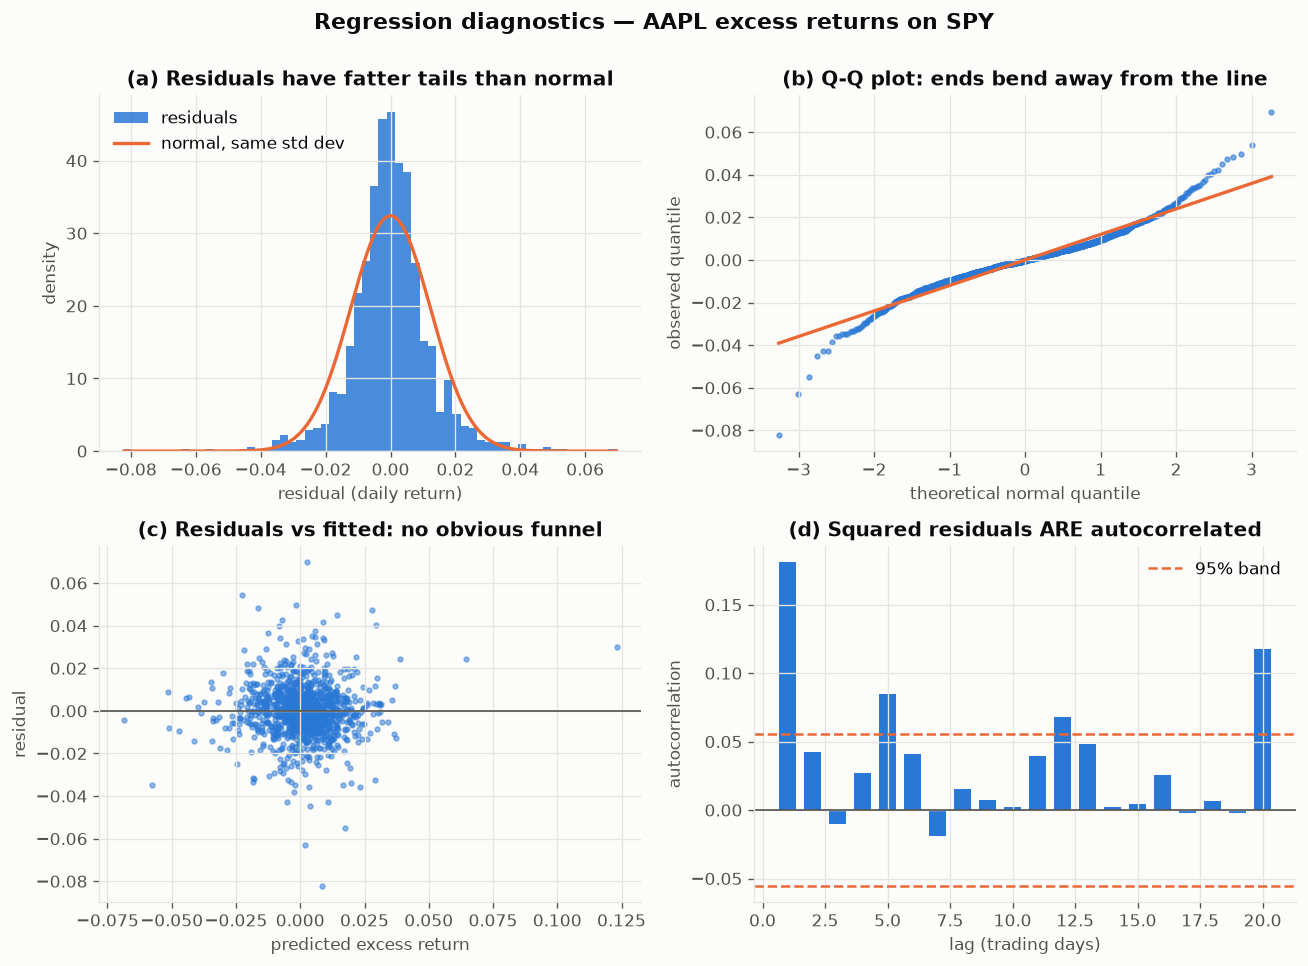

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))

# (a) residual distribution vs a normal with the same spread
ax[0,0].hist(resid, bins=60, color=BLUE, alpha=0.85, density=True, label="residuals")
grid_x = np.linspace(resid.min(), resid.max(), 300)
ax[0,0].plot(grid_x, stats.norm.pdf(grid_x, resid.mean(), resid.std()),
             color=ORANGE, lw=2, label="normal, same std dev")
ax[0,0].set_title("(a) Residuals have fatter tails than normal")
ax[0,0].set_xlabel("residual (daily return)"); ax[0,0].set_ylabel("density"); ax[0,0].legend()

# (b) Q-Q plot: quantiles of residuals vs quantiles of a normal
qq = stats.probplot(resid, dist="norm")
ax[0,1].scatter(qq[0][0], qq[0][1], s=8, color=BLUE, alpha=0.6)
ax[0,1].plot(qq[0][0], qq[1][1] + qq[1][0]*qq[0][0], color=ORANGE, lw=2)
ax[0,1].set_title("(b) Q-Q plot: ends bend away from the line")
ax[0,1].set_xlabel("theoretical normal quantile"); ax[0,1].set_ylabel("observed quantile")

# (c) residuals vs fitted: looking for a funnel shape
ax[1,0].scatter(model.fittedvalues, resid, s=8, color=BLUE, alpha=0.5)
ax[1,0].axhline(0, color=INK2, lw=1)
ax[1,0].set_title("(c) Residuals vs fitted: no obvious funnel")
ax[1,0].set_xlabel("predicted excess return"); ax[1,0].set_ylabel("residual")

# (d) autocorrelation of SQUARED residuals = volatility clustering
n_lags = 20
acf_sq = acf(resid ** 2, nlags=n_lags, fft=True)[1:]
conf   = 1.96 / np.sqrt(len(resid))
ax[1,1].bar(range(1, n_lags + 1), acf_sq, color=BLUE, width=0.7)
ax[1,1].axhline( conf, color=ORANGE, ls="--", lw=1.5, label="95% band")
ax[1,1].axhline(-conf, color=ORANGE, ls="--", lw=1.5)
ax[1,1].axhline(0, color=INK2, lw=1)
ax[1,1].set_title("(d) Squared residuals ARE autocorrelated")
ax[1,1].set_xlabel("lag (trading days)"); ax[1,1].set_ylabel("autocorrelation"); ax[1,1].legend()

fig.suptitle(f"Regression diagnostics — {FOCUS} excess returns on {MARKET}",
             fontsize=13, fontweight="bold", color=INK, y=1.00)
plt.tight_layout()
plt.savefig("fig3_diagnostics.png", dpi=150)
plt.show()

### What the tests say

**Normality: firmly rejected.** Kurtosis around 7.6, against 3.0 for a normal
distribution — panel (a) shows a tall narrow peak with fat tails, and panel (b) shows the
Q-Q points bending away at both ends. In plain terms: **extreme days happen far more often
than a bell curve predicts.** This is the single most reliable fact about financial returns,
and it is why "a 5-sigma event" happens in markets every few years instead of every few
millennia. With 1,254 observations the Central Limit Theorem still rescues the t-tests, so
this doesn't invalidate §2 — but it's the reason nobody should model market crashes as
normal.

**Constant variance: not rejected** (p ≈ 0.33), and panel (c) shows no funnel. Breusch–Pagan
only looks for variance that trends with the *predictor*, though — and panel (d) shows what
it misses.

**Independence over time: rejected, and this is the one that bites.** Residuals themselves
are only mildly autocorrelated, but **squared** residuals are strongly autocorrelated out to
20 lags. Squared residuals measure *size* of move regardless of direction, so this is
**volatility clustering**: turbulent days cluster together, calm days cluster together.
Markets have moods.

Volatility clustering breaks the "independent observations" assumption, which means the
standard errors in §2 are **too small** — 1,254 days contain less independent information
than 1,254 genuinely independent observations would.

### The fix: HAC standard errors

**HAC** = Heteroskedasticity- and Autocorrelation-Consistent, also called **Newey–West**.
It leaves the slope untouched and recomputes the standard error allowing nearby days to be
related. It is a one-argument change and it is the statistically correct thing to do here.

In [10]:
model_hac = sm.OLS(y, sm.add_constant(X)).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

se_table = pd.DataFrame({
    "beta":    [model.params.iloc[1],  model_hac.params.iloc[1]],
    "std err": [model.bse.iloc[1],     model_hac.bse.iloc[1]],
    "t vs 0":  [model.tvalues.iloc[1], model_hac.tvalues.iloc[1]],
    "CI low":  [model.conf_int().iloc[1,0], model_hac.conf_int().iloc[1,0]],
    "CI high": [model.conf_int().iloc[1,1], model_hac.conf_int().iloc[1,1]],
}, index=["plain OLS", "HAC (Newey-West)"])
print(se_table.round(4).to_string())
print(f"\nstandard error inflates by {(model_hac.bse.iloc[1]/model.bse.iloc[1] - 1)*100:.0f}%")

t1_hac = (model_hac.params.iloc[1] - 1) / model_hac.bse.iloc[1]
print(f"H0: beta = 1 under HAC -> t = {t1_hac:.2f}, "
      f"p = {2*(1-stats.norm.cdf(abs(t1_hac))):.4f}  (still rejected)")

                    beta  std err   t vs 0  CI low  CI high
plain OLS         1.1717   0.0321  36.5118  1.1087   1.2346
HAC (Newey-West)  1.1717   0.0471  24.8545  1.0793   1.2641

standard error inflates by 47%
H0: beta = 1 under HAC -> t = 3.64, p = 0.0003  (still rejected)


The slope is **identical** — HAC changes nothing about the estimate, only about the honesty
of the error bar around it. The standard error grows by roughly half, widening the interval
from about `[1.11, 1.24]` to `[1.08, 1.26]`.

The conclusion survives: beta is still distinguishable from 1. But had the original interval
been marginal, the naive version would have produced a confident claim that the corrected
version doesn't support. **Every confidence interval from here on uses HAC.**

---
## 4. What R² actually means here

"R² = 0.52" usually gets explained as "the model explains 52% of the variation," which is
true and forgettable. In this specific regression it has a concrete financial meaning worth
spelling out.

Start from the model itself. Apple's excess return on any day is the market part plus a
leftover:

$$ r_s \;=\; \alpha + \beta\, r_m + \varepsilon $$

Because the residual `ε` is uncorrelated with `r_m` by construction (least squares
guarantees it), the variances add with no cross-term:

$$ \underbrace{\sigma_s^2}_{\text{total risk}} \;=\; \underbrace{\beta^2 \sigma_m^2}_{\text{systematic}} \;+\; \underbrace{\sigma_\varepsilon^2}_{\text{idiosyncratic}} $$

- **Systematic risk** — the part that comes from being exposed to the market. You cannot
  diversify it away; holding more stocks doesn't help, because it's the thing they share.
- **Idiosyncratic risk** — Apple-specific: product launches, earnings surprises, regulation.
  This part *does* diversify away in a large portfolio.

And R² is exactly the systematic share of the total. That's the real interpretation:
**R² is the fraction of a stock's risk that diversification cannot remove.**

In [11]:
var_total = y.var(ddof=1)
var_sys   = beta**2 * X[MARKET].var(ddof=1)
var_idio  = resid.var(ddof=1)

print(f"total variance         {var_total:.8f}")
print(f"  systematic  b^2*s_m^2 {var_sys:.8f}   ({100*var_sys/var_total:.1f}%)")
print(f"  idiosyncratic  s_e^2  {var_idio:.8f}   ({100*var_idio/var_total:.1f}%)")
print(f"  sum                   {var_sys + var_idio:.8f}   <- matches total exactly")
print(f"\nR^2 from the regression = {model.rsquared:.4f}")
print(f"systematic share        = {var_sys/var_total:.4f}   <- the same number")
print()
print("in annualised volatility terms:")
print(f"  total         {np.sqrt(var_total*252)*100:5.1f}%")
print(f"  systematic    {np.sqrt(var_sys*252)*100:5.1f}%")
print(f"  idiosyncratic {np.sqrt(var_idio*252)*100:5.1f}%")

total variance         0.00031286
  systematic  b^2*s_m^2 0.00016134   (51.6%)
  idiosyncratic  s_e^2  0.00015152   (48.4%)
  sum                   0.00031286   <- matches total exactly

R^2 from the regression = 0.5157
systematic share        = 0.5157   <- the same number

in annualised volatility terms:
  total          28.1%
  systematic     20.2%
  idiosyncratic  19.5%


         beta     R2  total_vol  sys_vol  idio_vol
ticker                                            
AAPL    1.172  0.516     28.078   20.164    19.541
NVDA    2.137  0.500     52.028   36.781    36.798
MSFT    1.130  0.476     28.201   19.448    20.422
JPM     0.876  0.382     24.408   15.083    19.190
TSLA    2.029  0.340     59.893   34.925    48.656
NEE     0.530  0.115     26.876    9.117    25.282
WMT     0.411  0.100     22.412    7.075    21.266
PG      0.286  0.073     18.159    4.914    17.482
KO      0.256  0.070     16.672    4.414    16.077
XOM     0.399  0.066     26.653    6.863    25.754
JNJ     0.160  0.024     17.606    2.752    17.390


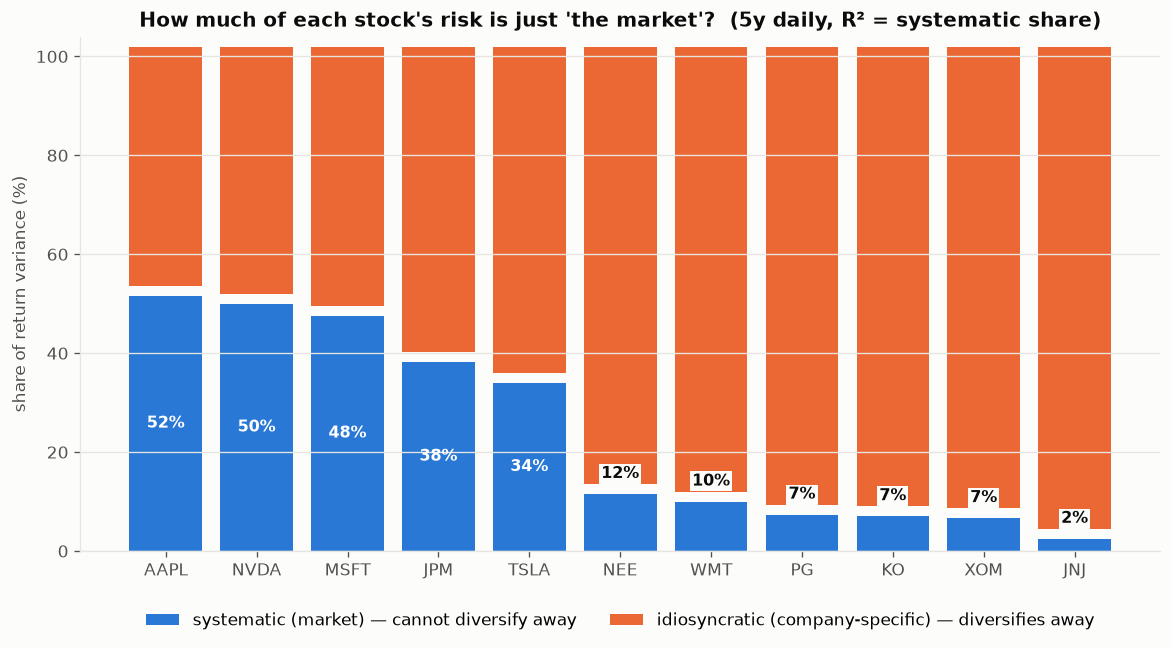

In [12]:
# Same decomposition for every stock, sorted by how market-driven each one is.
rows = []
for t in STOCKS:
    m = fit(excess[t], excess[[MARKET]])
    rows.append({"ticker": t,
                 "beta": m.params.iloc[1],
                 "R2": m.rsquared,
                 "total_vol": excess[t].std() * np.sqrt(252) * 100,
                 "sys_vol":   np.sqrt((m.params.iloc[1]**2) * excess[MARKET].var(ddof=1) * 252) * 100,
                 "idio_vol":  m.resid.std() * np.sqrt(252) * 100})
risk = pd.DataFrame(rows).set_index("ticker").sort_values("R2", ascending=False)
print(risk.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 5.5))
order = risk.index
sys_share  = (risk["R2"] * 100).values
idio_share = 100 - sys_share
ax.bar(order, sys_share,  color=BLUE,   label="systematic (market) — cannot diversify away")
ax.bar(order, idio_share, bottom=sys_share + 2, color=ORANGE,
       label="idiosyncratic (company-specific) — diversifies away")
for i, v in enumerate(sys_share):
    if v >= 15:                                  # label fits inside the blue segment
        ax.text(i, v/2, f"{v:.0f}%", ha="center", va="center",
                color="white", fontsize=9.5, fontweight="bold")
    else:                                        # segment too small — label just above it
        ax.text(i, v + 2.5, f"{v:.0f}%", ha="center", va="bottom",
                color=INK, fontsize=9.5, fontweight="bold",
                bbox=dict(facecolor=SURF, edgecolor="none", pad=1.2))
ax.set_ylabel("share of return variance (%)")
ax.set_title("How much of each stock's risk is just 'the market'?  (5y daily, R² = systematic share)")
ax.set_ylim(0, 104); ax.grid(axis="x", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.09), ncol=2)
plt.tight_layout(); plt.savefig("fig4_risk_decomposition.png", dpi=150); plt.show()

Even for Apple — one of the most market-linked stocks in the set — roughly **half** its
daily risk is company-specific. For the defensives (JNJ, KO, PG) the market explains well
under 20%, meaning a regression on the market is mostly *not* describing them at all.

This is the first hint of where the notebook ends up: an R² of 0.52 sounds like a decent
model, but restated as "half of Apple's risk has nothing to do with the market," it says the
single-factor model is leaving most of the story out.

---
## 5. Did beta actually change? — the Chow test

This is the question version 1 raised and couldn't answer.

The idea behind the **Chow test** is simple enough to explain without notation: fit **one**
line to the whole period, then fit **two** lines, one to each half. Two lines will always
fit at least as well as one — they have twice the parameters. The test asks whether they fit
*enough* better to be worth it, or whether the improvement is what you'd expect from the
extra flexibility alone.

$$ F \;=\; \frac{\big(\text{RSS}_{\text{pooled}} - (\text{RSS}_1 + \text{RSS}_2)\big) \big/ k}{(\text{RSS}_1 + \text{RSS}_2) \big/ (n - 2k)} $$

`RSS` is the residual sum of squares — the thing least squares minimises. `k = 2` parameters
(alpha and beta). A large `F` means splitting bought a real improvement.

**Choosing the split point honestly matters.** Version 1 used an 80/20 time-ordered split
chosen before seeing any result, so testing there is legitimate. Picking the date that
*looks* most broken and then testing it is circular — that comes next, with the caveat it
requires.

In [13]:
def chow_test(y_series, x_frame, split_position):
    """Chow test for a structural break at a given row position.
    Compares one pooled regression against two separate regressions."""
    n, k = len(y_series), 2

    rss_pooled = fit(y_series, x_frame).ssr
    rss_before = fit(y_series.iloc[:split_position], x_frame.iloc[:split_position]).ssr
    rss_after  = fit(y_series.iloc[split_position:], x_frame.iloc[split_position:]).ssr

    f_stat = ((rss_pooled - (rss_before + rss_after)) / k) / ((rss_before + rss_after) / (n - 2*k))
    p_val  = 1 - stats.f.cdf(f_stat, k, n - 2*k)
    return f_stat, p_val

n_days   = len(y)
split_80 = int(n_days * 0.8)
f_stat, p_val = chow_test(y, X, split_80)

beta_before = fit(y.iloc[:split_80], X.iloc[:split_80]).params.iloc[1]
beta_after  = fit(y.iloc[split_80:], X.iloc[split_80:]).params.iloc[1]

print(f"Split at the pre-specified 80/20 point: {y.index[split_80].date()}")
print(f"  beta before : {beta_before:.3f}   ({split_80} days)")
print(f"  beta after  : {beta_after:.3f}   ({n_days - split_80} days)")
print(f"\n  F({2}, {n_days-4}) = {f_stat:.2f}     p = {p_val:.2e}")
print(f"  5% critical value = {stats.f.ppf(0.95, 2, n_days-4):.2f}")
print("\n  -> " + ("REJECT stability: beta did not stay the same."
                   if p_val < 0.05 else "cannot reject stability."))

Split at the pre-specified 80/20 point: 2025-09-12
  beta before : 1.232   (1003 days)
  beta after  : 0.685   (251 days)

  F(2, 1250) = 15.14     p = 3.17e-07
  5% critical value = 3.00

  -> REJECT stability: beta did not stay the same.


**Rejected, overwhelmingly.** `F` is about five times the critical value and `p` is
vanishingly small. Version 1's out-of-sample failure was not bad luck — the relationship
genuinely changed.

### When did it change?

Running the same test at every possible break date turns one test into a search. The largest
`F` locates the most likely break — but **the ordinary F critical value no longer applies**,
because taking a maximum over ~900 tests will find a big value even in data with no break at
all. That's multiple testing, and ignoring it is a genuine mistake rather than a technicality.

The correct benchmark is the **sup-Wald** (Quandt–Andrews) distribution. Andrews (1993)
tabulates a 5% critical value near **12.4** for 2 parameters with 15% trimming — about four
times the naive value of 3.0. The 15% trimming means candidate dates in the first and last
15% of the sample are skipped, since a "break" with 30 days on one side is not estimable.

In [14]:
lo_i, hi_i = int(n_days * 0.15), int(n_days * 0.85)
f_scan = pd.Series({y.index[i]: chow_test(y, X, i)[0] for i in range(lo_i, hi_i)})

break_date = f_scan.idxmax()
break_pos  = int(y.index.get_loc(break_date))
ANDREWS_5PCT = 12.4

print(f"scanned {len(f_scan)} candidate dates")
print(f"max F = {f_scan.max():.2f} on {break_date.date()}")
print(f"  naive 5% F critical value  : {stats.f.ppf(0.95, 2, n_days-4):.2f}   (NOT valid after searching)")
print(f"  Andrews sup-Wald 5% approx : {ANDREWS_5PCT:.1f}   <- the right bar")
print(f"  -> {'exceeds' if f_scan.max() > ANDREWS_5PCT else 'does NOT exceed'} the corrected threshold")
print(f"\nbeta before {break_date.date()}: {fit(y.iloc[:break_pos], X.iloc[:break_pos]).params.iloc[1]:.3f}")
print(f"beta after  {break_date.date()}: {fit(y.iloc[break_pos:], X.iloc[break_pos:]).params.iloc[1]:.3f}")
print("\ntop 5 candidate dates (note how tightly they cluster — one event, not scattered noise):")
print(f_scan.nlargest(5).round(2).to_string())

scanned 877 candidate dates
max F = 18.23 on 2025-10-28
  naive 5% F critical value  : 3.00   (NOT valid after searching)
  Andrews sup-Wald 5% approx : 12.4   <- the right bar
  -> exceeds the corrected threshold

beta before 2025-10-28: 1.235
beta after  2025-10-28: 0.598

top 5 candidate dates (note how tightly they cluster — one event, not scattered noise):
2025-10-28    18.23
2025-10-29    18.22
2025-10-30    18.21
2025-10-27    17.69
2025-10-23    17.59


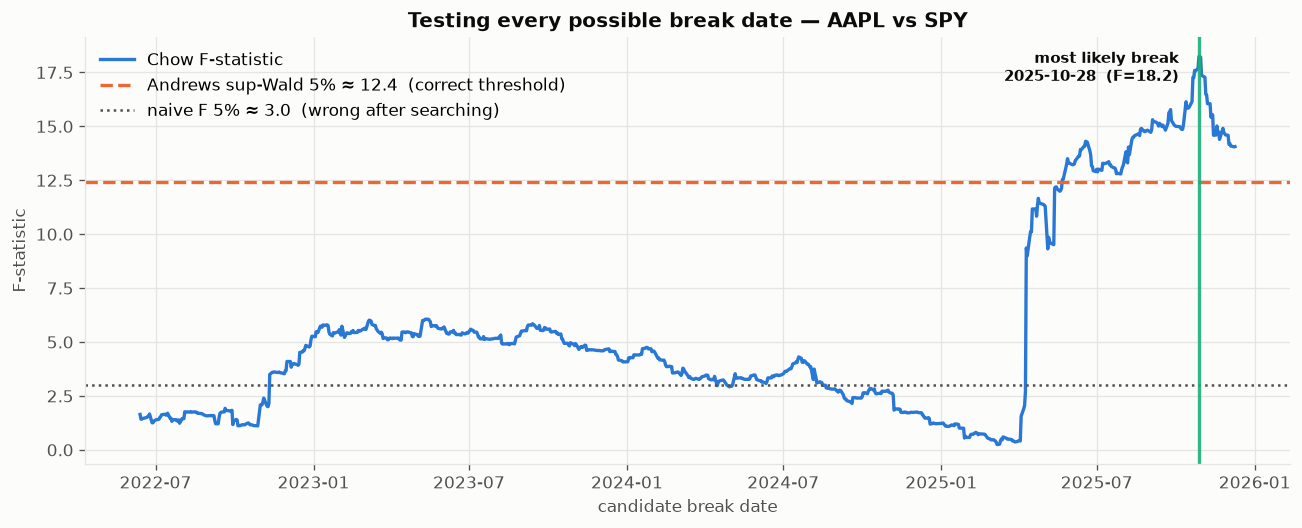

In [15]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(f_scan.index, f_scan.values, color=BLUE, lw=2, label="Chow F-statistic")
ax.axhline(ANDREWS_5PCT, color=ORANGE, ls="--", lw=2,
           label=f"Andrews sup-Wald 5% ≈ {ANDREWS_5PCT}  (correct threshold)")
ax.axhline(stats.f.ppf(0.95, 2, n_days-4), color=INK2, ls=":", lw=1.5,
           label="naive F 5% ≈ 3.0  (wrong after searching)")
ax.axvline(break_date, color=AQUA, lw=2, alpha=0.9)
ax.annotate(f"most likely break\n{break_date.date()}  (F={f_scan.max():.1f})",
            xy=(break_date, f_scan.max()), xytext=(-12, 4), textcoords="offset points",
            color=INK, fontsize=9, fontweight="bold", va="top", ha="right")
ax.set_ylabel("F-statistic"); ax.set_xlabel("candidate break date")
ax.set_title(f"Testing every possible break date — {FOCUS} vs {MARKET}")
ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig("fig5_break_scan.png", dpi=150); plt.show()

The evidence clears even the conservative bar, so **a break happened**.

But read the shape of that curve rather than just its peak, because it qualifies the claim.
The F-statistic climbs steeply from early 2025 and then sits on a **broad plateau** above the
threshold for months. Many nearby dates fit nearly as well as the winner. So the evidence is
strong that beta changed, and weak about exactly *when* — this is a gradual regime shift being
approximated by a model that is only allowed to express a single cliff. "Late October 2025"
is the best point estimate, not a datable event, and §6 shows why that distinction matters.

---
## 6. Beta through time

A single break date is a crude description of something continuous. **Rolling beta** —
recomputing on a moving window — shows the whole path.

The window length is a genuine bias/variance tradeoff, so both are plotted:
- **60 days (~3 months)** reacts fast but is noisy.
- **252 days (~1 year)** is smooth but slow to notice change.

Neither is "correct." Note the two lines are on the *same* axis and measure the *same*
quantity — this is a comparison, not a dual-axis chart.

In [16]:
def rolling_beta(stock_returns, market_returns, window):
    """Beta recomputed on a moving window, using beta = cov / var."""
    cov = stock_returns.rolling(window).cov(market_returns)
    var = market_returns.rolling(window).var()
    return (cov / var).dropna()

rb_60  = rolling_beta(excess[FOCUS], excess[MARKET], 60)
rb_252 = rolling_beta(excess[FOCUS], excess[MARKET], 252)

# Average pairwise correlation among the 11 stocks, on the same 60-day window.
def average_pairwise_correlation(frame):
    c = frame.corr().values
    return c[np.triu_indices_from(c, k=1)].mean()

roll_corr = pd.Series({
    excess.index[i]: average_pairwise_correlation(excess[STOCKS].iloc[i-60:i])
    for i in range(60, len(excess))
})

print(f"60-day beta : min {rb_60.min():.2f}  max {rb_60.max():.2f}  "
      f"mean {rb_60.mean():.2f}  latest {rb_60.iloc[-1]:.2f}")
print(f"252-day beta: min {rb_252.min():.2f}  max {rb_252.max():.2f}  "
      f"mean {rb_252.mean():.2f}  latest {rb_252.iloc[-1]:.2f}")
print(f"\nthe 60-day estimate spans {rb_60.max()-rb_60.min():.2f} beta points over five years.")

60-day beta : min -0.04  max 1.61  mean 1.08  latest 0.02
252-day beta: min 0.68  max 1.35  mean 1.15  latest 0.69

the 60-day estimate spans 1.65 beta points over five years.


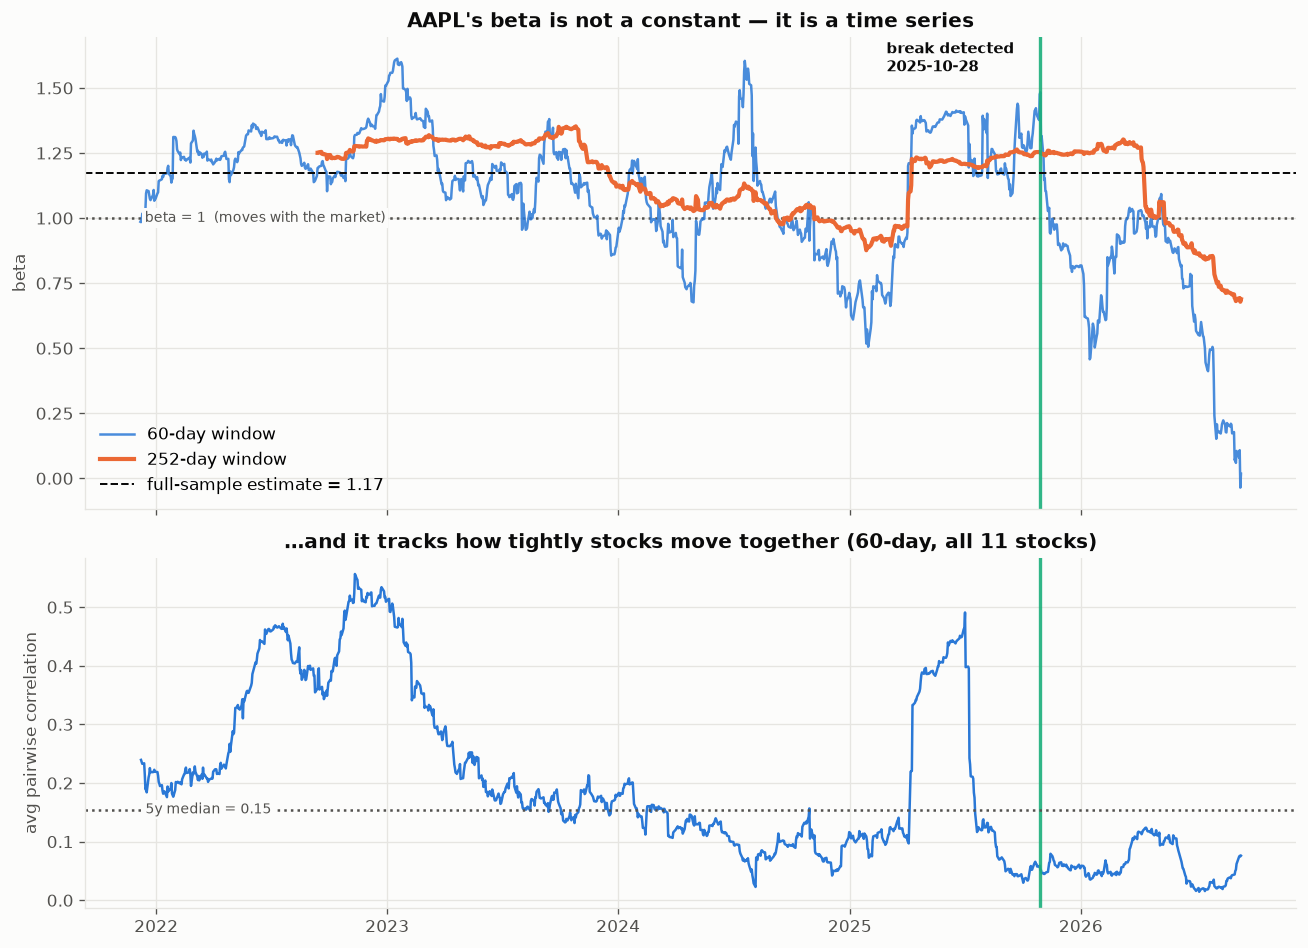

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={"height_ratios": [1.35, 1]})

ax1.axhline(1.0, color=INK2, ls=":", lw=1.5)
ax1.text(rb_60.index[5], 1.0, "beta = 1  (moves with the market)", fontsize=8.5, color=INK2,
         va="center", bbox=dict(facecolor=SURF, edgecolor="none", pad=1.5))
ax1.plot(rb_60.index,  rb_60.values,  color=BLUE,   lw=1.5, alpha=0.85, label="60-day window")
ax1.plot(rb_252.index, rb_252.values, color=ORANGE, lw=2.5, label="252-day window")
ax1.axvline(break_date, color=AQUA, lw=2, alpha=0.9)
ax1.annotate(f"break detected\n{break_date.date()}", xy=(break_date, rb_60.max()*0.97),
             xytext=(-92, 0), textcoords="offset points", fontsize=9,
             fontweight="bold", color=INK)
ax1.axhline(beta, color=INK, ls="--", lw=1.2,
            label=f"full-sample estimate = {beta:.2f}")
ax1.set_ylabel("beta"); ax1.legend(loc="lower left")
ax1.set_title(f"{FOCUS}'s beta is not a constant — it is a time series")

ax2.plot(roll_corr.index, roll_corr.values, color=BLUE, lw=1.5)
ax2.axvline(break_date, color=AQUA, lw=2, alpha=0.9)
ax2.axhline(roll_corr.median(), color=INK2, ls=":", lw=1.5)
ax2.text(roll_corr.index[5], roll_corr.median(),
         f"5y median = {roll_corr.median():.2f}", fontsize=8.5, color=INK2, va="center",
         bbox=dict(facecolor=SURF, edgecolor="none", pad=1.5))
ax2.set_ylabel("avg pairwise correlation"); ax2.set_xlabel("")
ax2.set_title("…and it tracks how tightly stocks move together (60-day, all 11 stocks)")

plt.tight_layout(); plt.savefig("fig6_rolling_beta.png", dpi=150); plt.show()

The full-sample estimate of ~1.17 (dashed line) is a number the rolling series spends
much of its time nowhere near. It is an *average of a moving thing*, not a property Apple has.

It also complicates §5 in a way worth stating plainly rather than hiding: **beta does not sit
still and then drop once.** The 60-day series swings between roughly 0 and 1.6 across five
years, and it dipped near 0.5 in late 2024 too, well before the "break." The Chow test asks a
yes/no question — *is one line enough?* — and the answer is a clear no. It is not evidence
that beta was constant until October 2025 and constant after. A two-regime model is a better
description than one regime, and a rolling estimate is better than either.

The second panel is why the notebook carried eleven stocks instead of one: **beta falls when
cross-stock correlation falls**, and the two series move together across the whole period, not
just at the break. That alignment is the thread the rest of the notebook pulls. Note too that
correlation has been drifting down since 2022 with sharp spikes — another reason to read this
as a cycle rather than a one-time event.

---
## 7. Is this an Apple story, or a market story?

The obvious reading of §5 is "something happened at Apple." That reading is testable, and it
has an obvious control: **if it were Apple-specific, no other stock's beta should have moved.**

In [18]:
pre  = excess[excess.index <  break_date]
post = excess[excess.index >= break_date]
print(f"pre-break:  {len(pre):4d} days   ({pre.index.min().date()} to {pre.index.max().date()})")
print(f"post-break: {len(post):4d} days   ({post.index.min().date()} to {post.index.max().date()})\n")

rows = []
for t in STOCKS:
    m_pre, m_post = fit(pre[t], pre[[MARKET]]), fit(post[t], post[[MARKET]])
    b1, s1 = m_pre.params.iloc[1],  m_pre.bse.iloc[1]
    b2, s2 = m_post.params.iloc[1], m_post.bse.iloc[1]
    z = (b2 - b1) / np.sqrt(s1**2 + s2**2)        # two-sample z on the difference
    rows.append({"ticker": t, "beta_pre": b1, "beta_post": b2, "change": b2 - b1,
                 "z": z, "p": 2 * (1 - stats.norm.cdf(abs(z))),
                 "R2_pre": m_pre.rsquared, "R2_post": m_post.rsquared})

cross = pd.DataFrame(rows).set_index("ticker").sort_values("change")
print(cross.round(3).to_string())
print(f"\nbetas that FELL:  {(cross['change'] < 0).sum()} of {len(cross)}")
print(f"mean change across all stocks: {cross['change'].mean():+.3f}")
print(f"mean R2 fell from {cross['R2_pre'].mean():.3f} to {cross['R2_post'].mean():.3f}")
print(f"significant at 5%: {', '.join(cross[cross['p'] < 0.05].index)}")

pre-break:  1035 days   (2021-09-14 to 2025-10-27)
post-break:  219 days   (2025-10-28 to 2026-09-11)

        beta_pre  beta_post  change      z      p  R2_pre  R2_post
ticker                                                            
XOM        0.516     -0.656  -1.172 -8.474  0.000   0.121    0.103
AAPL       1.235      0.598  -0.637 -4.979  0.000   0.599    0.097
KO         0.312     -0.241  -0.552 -5.451  0.000   0.121    0.027
WMT        0.463     -0.059  -0.522 -3.645  0.000   0.151    0.001
NEE        0.576      0.116  -0.460 -3.872  0.000   0.137    0.005
JNJ        0.199     -0.197  -0.396 -3.702  0.000   0.044    0.017
PG         0.319     -0.016  -0.335 -3.036  0.002   0.106    0.000
NVDA       2.160      1.935  -0.225 -1.347  0.178   0.509    0.423
MSFT       1.147      0.975  -0.173 -1.024  0.306   0.595    0.137
JPM        0.888      0.771  -0.117 -1.060  0.289   0.415    0.197
TSLA       2.010      2.210   0.200  0.958  0.338   0.335    0.385

betas that FELL:  10 of 1

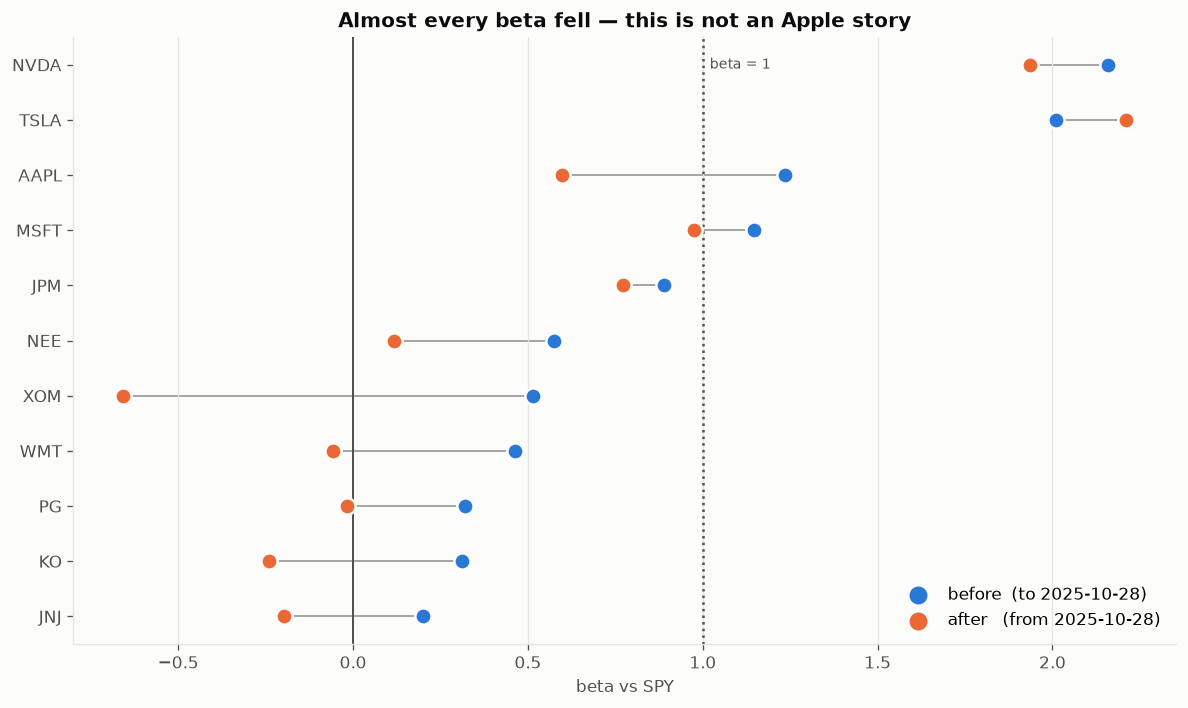

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
order = cross.sort_values("beta_pre").index
ypos  = np.arange(len(order))

for i, t in enumerate(order):
    a, b = cross.loc[t, "beta_pre"], cross.loc[t, "beta_post"]
    ax.plot([a, b], [i, i], color=INK2, lw=1.2, alpha=0.5, zorder=1)
    ax.scatter(a, i, s=95, color=BLUE,   zorder=3, edgecolor=SURF, linewidth=1.5)
    ax.scatter(b, i, s=95, color=ORANGE, zorder=3, edgecolor=SURF, linewidth=1.5)

ax.scatter([], [], s=95, color=BLUE,   label=f"before  (to {break_date.date()})")
ax.scatter([], [], s=95, color=ORANGE, label=f"after   (from {break_date.date()})")
ax.axvline(0,   color=INK2, lw=1.2)
ax.axvline(1.0, color=INK2, ls=":", lw=1.5)
ax.text(1.02, len(order)-1.0, "beta = 1", fontsize=8.5, color=INK2,
        va="center", bbox=dict(facecolor=SURF, edgecolor="none", pad=1.5))
ax.set_yticks(ypos); ax.set_yticklabels(order)
ax.set_xlabel("beta vs SPY"); ax.grid(axis="y", visible=False)
ax.set_title("Almost every beta fell — this is not an Apple story")
ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig("fig7_cross_section.png", dpi=150); plt.show()

**Ten of eleven betas fell**, by an average of about −0.40. Five defensive names went
*negative*, meaning that over this stretch they drifted opposite the index. Average R²
collapsed across the board. Whatever happened in late October 2025, it did not happen to
Apple — it happened to the market.

So my first explanation was wrong. Worth stating plainly, because the next two candidate
explanations are also testable, and one of them is also wrong.

### Candidate explanation: index concentration?

A plausible story: the S&P 500 is cap-weighted, so if a handful of enormous AI-related names
started driving the index, then "the market" stopped meaning "stocks in general" and the
other 490 would appear to decouple from it.

That predicts something specific and checkable: the effect should be **much weaker against an
equal-weighted benchmark**, where no single company dominates. `RSP` was downloaded in §1
for exactly this test.

In [20]:
comp = []
for t in STOCKS:
    comp.append({"ticker": t,
                 "SPY_pre":  fit(pre[t],  pre[["SPY"]]).params.iloc[1],
                 "SPY_post": fit(post[t], post[["SPY"]]).params.iloc[1],
                 "RSP_pre":  fit(pre[t],  pre[["RSP"]]).params.iloc[1],
                 "RSP_post": fit(post[t], post[["RSP"]]).params.iloc[1]})
bench = pd.DataFrame(comp).set_index("ticker")
bench["SPY_change"] = bench.SPY_post - bench.SPY_pre
bench["RSP_change"] = bench.RSP_post - bench.RSP_pre
print(bench.round(3).to_string())
print(f"\nmean beta change vs SPY (cap-weighted)   : {bench.SPY_change.mean():+.3f}")
print(f"mean beta change vs RSP (equal-weighted) : {bench.RSP_change.mean():+.3f}")
print("\n-> nearly identical. The concentration explanation is WRONG.")

        SPY_pre  SPY_post  RSP_pre  RSP_post  SPY_change  RSP_change
ticker                                                              
AAPL      1.235     0.598    1.110     0.567      -0.637      -0.543
MSFT      1.147     0.975    0.951     0.370      -0.173      -0.582
NVDA      2.160     1.935    1.746     0.799      -0.225      -0.947
TSLA      2.010     2.210    1.792     1.388       0.200      -0.404
JPM       0.888     0.771    0.993     1.000      -0.117       0.007
XOM       0.516    -0.656    0.677    -0.393      -1.172      -1.071
WMT       0.463    -0.059    0.481     0.290      -0.522      -0.191
KO        0.312    -0.241    0.408     0.182      -0.552      -0.226
PG        0.319    -0.016    0.401     0.427      -0.335       0.026
JNJ       0.199    -0.197    0.300     0.229      -0.396      -0.071
NEE       0.576     0.116    0.727     0.419      -0.460      -0.308

mean beta change vs SPY (cap-weighted)   : -0.399
mean beta change vs RSP (equal-weighted) : -0.392

-

**Falsified.** The betas fall just as much against the equal-weighted index. Index
concentration is not the mechanism.

### The mechanism: correlation collapse

Back to the identity from §2, which is the right tool because it splits beta into two parts
that can move independently:

$$ \beta \;=\; \underbrace{\operatorname{Corr}(r_s, r_m)}_{\text{how tightly it tracks}} \times \underbrace{\frac{\sigma_s}{\sigma_m}}_{\text{how much more it moves}} $$

Beta fell. So at least one factor fell. Which one — and did the other help or fight it?

In [21]:
mech = []
for t in STOCKS:
    mech.append({"ticker": t,
                 "corr_pre":  pre[t].corr(pre[MARKET]),
                 "corr_post": post[t].corr(post[MARKET]),
                 "volratio_pre":  pre[t].std()  / pre[MARKET].std(),
                 "volratio_post": post[t].std() / post[MARKET].std()})
mech = pd.DataFrame(mech).set_index("ticker")
print(mech.round(3).to_string())

c1, c2 = mech.corr_pre.mean(), mech.corr_post.mean()
v1, v2 = mech.volratio_pre.mean(), mech.volratio_post.mean()

print(f"\n                        before    after")
print(f"mean correlation       {c1:7.3f}  {c2:7.3f}   ({c2-c1:+.3f})")
print(f"mean volatility ratio  {v1:7.3f}  {v2:7.3f}   ({v2-v1:+.3f})")
print(f"mean beta = product    {c1*v1:7.3f}  {c2*v2:7.3f}   ({c2*v2-c1*v1:+.3f})")
print("\ncounterfactuals — change one factor at a time:")
print(f"  if ONLY correlation had changed : beta {c1*v1:.3f} -> {c2*v1:.3f}  ({c2*v1-c1*v1:+.3f})")
print(f"  if ONLY the vol ratio had changed: beta {c1*v1:.3f} -> {c1*v2:.3f}  ({c1*v2-c1*v1:+.3f})")

        corr_pre  corr_post  volratio_pre  volratio_post
ticker                                                  
AAPL       0.774      0.311         1.596          1.922
MSFT       0.771      0.370         1.488          2.634
NVDA       0.713      0.650         3.028          2.975
TSLA       0.579      0.620         3.470          3.563
JPM        0.644      0.444         1.378          1.737
XOM        0.348     -0.321         1.483          2.044
WMT        0.389     -0.029         1.191          2.049
KO         0.347     -0.165         0.897          1.462
PG         0.325     -0.010         0.982          1.569
JNJ        0.210     -0.129         0.949          1.530
NEE        0.370      0.072         1.555          1.623

                        before    after
mean correlation         0.497    0.165   (-0.332)
mean volatility ratio    1.638    2.101   (+0.463)
mean beta = product      0.815    0.346   (-0.468)

counterfactuals — change one factor at a time:
  if ONLY correla

In [22]:
print("market and single-stock volatility, annualised:")
for b in ["SPY", "RSP"]:
    print(f"  {b}: {pre[b].std()*np.sqrt(252)*100:5.1f}%  ->  {post[b].std()*np.sqrt(252)*100:5.1f}%")
print(f"  average single stock: {pre[STOCKS].std().mean()*np.sqrt(252)*100:5.1f}%"
      f"  ->  {post[STOCKS].std().mean()*np.sqrt(252)*100:5.1f}%")
print(f"\naverage pairwise correlation among the 11 stocks: "
      f"{average_pairwise_correlation(pre[STOCKS]):.3f}  ->  {average_pairwise_correlation(post[STOCKS]):.3f}")

market and single-stock volatility, annualised:
  SPY:  18.0%  ->   13.0%
  RSP:  17.0%  ->   11.8%
  average single stock:  29.4%  ->   27.4%

average pairwise correlation among the 11 stocks: 0.254  ->  0.058


### The answer

**Correlation collapsed, and it did all the work.** Average correlation with the market fell
from about 0.50 to about 0.17. Average *pairwise* correlation between the stocks fell from
roughly 0.25 to under 0.06 — they nearly stopped moving together at all.

The volatility ratio moved in the **opposite** direction, rising from ~1.64 to ~2.10, which
on its own would have pushed betas *up*. The correlation collapse was large enough to
overwhelm it.

And the rising volatility ratio is not a separate fact — it is the same fact seen from
another angle. Individual stocks stayed roughly as volatile as before (≈29% annualised, down
only slightly), while the **index** got much calmer (18% → 13%). That is what happens when correlations
fall: an index is a portfolio, and a portfolio of things that no longer move together
diversifies itself. The market got quieter *because* its components stopped agreeing.

So the full causal chain is one thing, not three:

> **Correlation collapsed** → the index became calmer than its components → the volatility
> ratio rose → but not enough to offset → **betas fell across the board, and R² fell with
> them** (R² is correlation squared, so halving correlation quarters R²).

This is a **low-correlation, high-dispersion regime**: stocks trading on their own news
rather than on macro. Version 1's "Apple decoupled from the market" was the right
observation attached to the wrong subject. *Everything* decoupled.

---
## 8. Trying to break the finding

A result that survives only under the exact choices that produced it isn't a result. Three
ways this could still be an artifact:

1. **A few extreme days** driving everything.
2. **The break date was chosen by searching** — maybe any split tells this story.
3. **It might be unremarkable** — low correlation may just be normal and unworthy of comment.

In [23]:
print("CHECK 1 — drop the most extreme 5% of market days")
for label, frame in [("before", pre), ("after", post)]:
    cutoff = frame[MARKET].abs().quantile(0.95)
    trimmed = frame[frame[MARKET].abs() <= cutoff]
    full_b = np.mean([fit(frame[t],   frame[[MARKET]]).params.iloc[1]   for t in STOCKS])
    trim_b = np.mean([fit(trimmed[t], trimmed[[MARKET]]).params.iloc[1] for t in STOCKS])
    print(f"  {label:6s} mean beta: all days {full_b:.3f} | excluding extremes {trim_b:.3f}")

print("\nCHECK 2 — use plain calendar dates instead of the searched break")
for cut in ["2025-09-01", "2025-12-01", "2026-01-01", "2026-03-01"]:
    c = pd.Timestamp(cut)
    a, b = excess[excess.index < c], excess[excess.index >= c]
    if len(b) < 60:
        continue
    ba = np.mean([fit(a[t], a[[MARKET]]).params.iloc[1] for t in STOCKS])
    bb = np.mean([fit(b[t], b[[MARKET]]).params.iloc[1] for t in STOCKS])
    ca = np.mean([a[t].corr(a[MARKET]) for t in STOCKS])
    cb = np.mean([b[t].corr(b[MARKET]) for t in STOCKS])
    print(f"  split {cut} (n after = {len(b):4d}): mean beta {ba:.3f} -> {bb:.3f}  |  mean corr {ca:.3f} -> {cb:.3f}")

print("\nCHECK 3 — how unusual is the current correlation level, historically?")
latest = roll_corr.iloc[-1]
pct = 100 * (roll_corr < latest).mean()
print(f"  60-day avg pairwise correlation now : {latest:.3f}")
print(f"  5-year range                        : {roll_corr.min():.3f} to {roll_corr.max():.3f}")
print(f"  5-year median                       : {roll_corr.median():.3f}")
print(f"  percentile rank of today's value    : {pct:.0f} out of 100")

CHECK 1 — drop the most extreme 5% of market days
  before mean beta: all days 0.893 | excluding extremes 0.895
  after  mean beta: all days 0.494 | excluding extremes 0.481

CHECK 2 — use plain calendar dates instead of the searched break
  split 2025-09-01 (n after =  259): mean beta 0.896 -> 0.516  |  mean corr 0.503 -> 0.173
  split 2025-12-01 (n after =  196): mean beta 0.889 -> 0.480  |  mean corr 0.493 -> 0.158
  split 2026-01-01 (n after =  174): mean beta 0.887 -> 0.485  |  mean corr 0.490 -> 0.161
  split 2026-03-01 (n after =  135): mean beta 0.882 -> 0.473  |  mean corr 0.479 -> 0.162

CHECK 3 — how unusual is the current correlation level, historically?
  60-day avg pairwise correlation now : 0.076
  5-year range                        : 0.014 to 0.557
  5-year median                       : 0.155
  percentile rank of today's value    : 22 out of 100


**Check 1 passes.** Removing the 5% most extreme market days moves mean beta by at most ~0.013,
against a shift of 0.40 that needs explaining. Not an outlier artifact.

**Check 2 passes.** Every arbitrary calendar split from September 2025 onward reproduces the
same shift. The finding does not depend on the searched date.

**Check 3 is the one that adds nuance, and it cuts against overclaiming.** Today's
correlation sits around the **22nd percentile** of its own five-year history — low, but
nowhere near a record, and above the sample minimum. So the honest framing is *not* "markets
have entered an unprecedented regime." It is: **correlation is cyclical, it is currently in
the low part of its range, and beta estimates move with it.** That is a more modest claim
and it is the one the data supports.

---
## 9. So which beta should you actually quote?

If you look up Apple's beta on three finance sites you'll get three different numbers. Not
because anyone is wrong — because "beta" isn't fully specified until you state a **window**
and a **sampling frequency**, and providers choose differently. Yahoo Finance uses 5 years of
*monthly* returns; Bloomberg conventionally uses 2 years of *weekly*.

In [24]:
def beta_for(price_frame, resample_rule=None):
    """Beta of FOCUS vs MARKET at a given sampling frequency, with HAC standard errors."""
    p = price_frame.resample(resample_rule).last() if resample_rule else price_frame
    r = p.pct_change().dropna()
    m = sm.OLS(r[FOCUS], sm.add_constant(r[[MARKET]])).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
    ci = m.conf_int().iloc[1]
    return m.params.iloc[1], m.bse.iloc[1], ci.iloc[0], ci.iloc[1], m.rsquared, len(r)

two_y = prices[prices.index >= prices.index.max() - pd.Timedelta(days=730)]
one_y = prices[prices.index >= prices.index.max() - pd.Timedelta(days=365)]

specs = [("5y daily",              prices, None),
         ("5y weekly",             prices, "W-FRI"),
         ("5y monthly  (Yahoo)",   prices, "ME"),
         ("2y daily  (version 1)", two_y,  None),
         ("2y weekly  (Bloomberg)",two_y,  "W-FRI"),
         ("1y daily",              one_y,  None)]

est = pd.DataFrame([dict(zip(["beta","se","lo","hi","R2","n"], beta_for(p, r)))
                    for _, p, r in specs], index=[s[0] for s in specs])
print(est.round(3).to_string())
print(f"\nspread between the highest and lowest estimate: {est.beta.max()-est.beta.min():.3f} beta points")

                         beta     se     lo     hi     R2     n
5y daily                1.171  0.044  1.086  1.257  0.516  1254
5y weekly               1.150  0.074  1.004  1.295  0.460   260
5y monthly  (Yahoo)     1.069  0.128  0.819  1.319  0.459    60
2y daily  (version 1)   1.081  0.115  0.854  1.307  0.379   501
2y weekly  (Bloomberg)  1.070  0.162  0.752  1.388  0.312   104
1y daily                0.685  0.119  0.451  0.919  0.123   251

spread between the highest and lowest estimate: 0.487 beta points


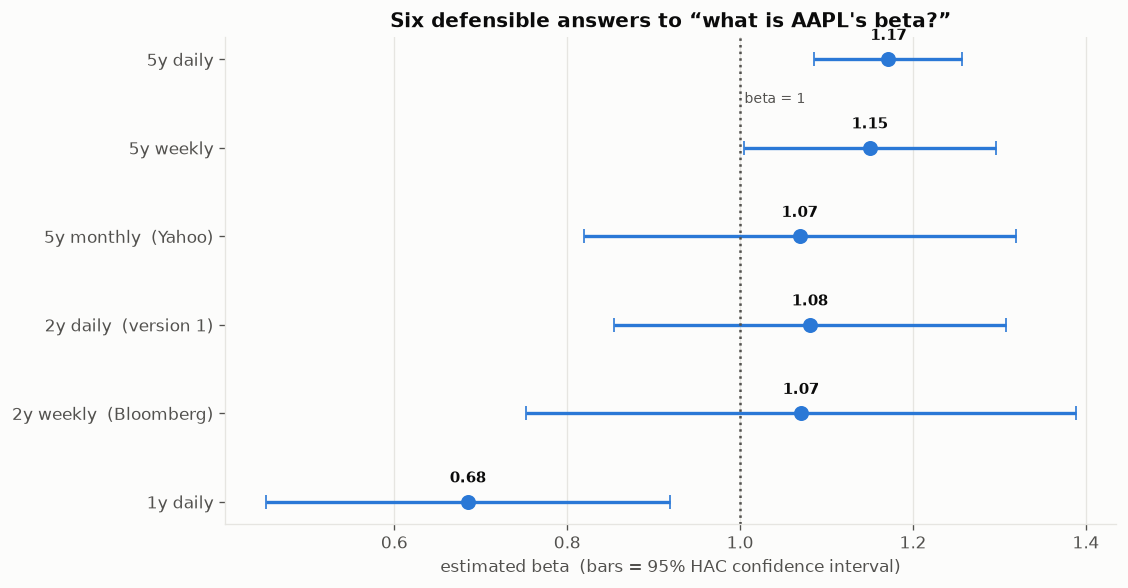

In [25]:
fig, ax = plt.subplots(figsize=(9.5, 5))
ypos = np.arange(len(est))[::-1]
ax.errorbar(est.beta, ypos, xerr=[est.beta-est.lo, est.hi-est.beta],
            fmt="o", color=BLUE, ecolor=BLUE, elinewidth=2, capsize=4, markersize=8)
ax.axvline(1.0, color=INK2, ls=":", lw=1.5)
ax.text(1.005, ypos.max()-0.45, "beta = 1", fontsize=8.5, color=INK2,
        va="center", bbox=dict(facecolor=SURF, edgecolor="none", pad=1.5))
for yv, bv in zip(ypos, est.beta):
    ax.text(bv, yv + 0.22, f"{bv:.2f}", ha="center", fontsize=9, color=INK, fontweight="bold")
ax.set_yticks(ypos); ax.set_yticklabels(est.index)
ax.set_xlabel(f"estimated beta  (bars = 95% HAC confidence interval)")
ax.set_title(f"Six defensible answers to “what is {FOCUS}'s beta?”")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.savefig("fig8_which_beta.png", dpi=150); plt.show()

Every one of these is a defensible estimate, and they disagree by a wide margin. The 1-year
daily figure is the low outlier — it sits almost entirely inside the post-break regime, so it
is measuring the new correlation environment rather than disagreeing about method.

### Does shrinkage help? (testing a textbook rule instead of quoting it)

Because betas are noisy and were historically observed to drift toward 1, Blume (1971)
proposed reporting an **adjusted beta**:

$$ \beta_{\text{adj}} = 0.67\,\beta_{\text{raw}} + 0.33 \times 1.0 $$

Bloomberg still displays this. It is easy to quote. It is also easy to *test*: fit beta on one
year, then check which estimate better predicted the beta actually realised in the following
year — raw, Blume-adjusted, or just assuming 1.0.

In [26]:
hist = yf.download(STOCKS + [MARKET], period="10y", auto_adjust=True,
                   progress=False)["Close"].pct_change().dropna()
W = 252
past_beta, next_beta = [], []
for t in STOCKS:
    for i in range(W, len(hist) - W, 21):          # step a month at a time
        a, b = hist.iloc[i-W:i], hist.iloc[i:i+W]
        past_beta.append(np.cov(a[t], a[MARKET])[0, 1] / a[MARKET].var())
        next_beta.append(np.cov(b[t], b[MARKET])[0, 1] / b[MARKET].var())
past_beta, next_beta = np.array(past_beta), np.array(next_beta)

def rmse(prediction):
    return np.sqrt(np.mean((prediction - next_beta) ** 2))

print(f"{len(past_beta)} stock-windows over 10 years\n")
print(f"  RMSE, raw prior beta        : {rmse(past_beta):.4f}")
print(f"  RMSE, Blume-adjusted        : {rmse(0.67*past_beta + 0.33):.4f}")
print(f"  RMSE, always assume 1.0     : {rmse(np.ones_like(past_beta)):.4f}")

weights = np.linspace(0, 1.4, 141)
best_w  = weights[int(np.argmin([rmse(w*past_beta + (1-w)) for w in weights]))]
slope, intercept = np.polyfit(past_beta, next_beta, 1)
print(f"\n  best-fitting shrinkage weight here : {best_w:.2f}   (Blume assumes 0.67)")
print(f"  pooled fit: next_beta = {slope:.3f} * past_beta + {intercept:.3f}")

1056 stock-windows over 10 years

  RMSE, raw prior beta        : 0.2995
  RMSE, Blume-adjusted        : 0.3366
  RMSE, always assume 1.0     : 0.6274

  best-fitting shrinkage weight here : 0.94   (Blume assumes 0.67)
  pooled fit: next_beta = 0.932 * past_beta + 0.035


**Blume shrinkage makes the prediction worse on this sample** — RMSE rises by about 12%. The
best-fitting weight is ~0.94, not 0.67, and the pooled relationship has a slope near 0.93:
for these stocks, beta persists far more than Blume's rule assumes, so shrinking toward 1.0
throws away real signal.

**This is not a refutation of Blume.** Eleven hand-picked large-caps is not a random
cross-section, and Blume's coefficient came from a broad universe including small, noisy
firms whose betas are estimated badly and genuinely do revert more. The honest conclusion is
narrower and more useful: *the shrinkage constant is a property of the universe you apply it
to, and it is checkable rather than something to inherit.*

Both estimates crush "assume 1.0," so beta estimation is clearly doing something real.

---
## 10. What I'd claim, and what I wouldn't

### What the evidence supports

1. **Apple's beta over the last five years is about 1.17**, 95% HAC interval roughly
   `[1.08, 1.26]` — statistically distinguishable from 1. Apple has amplified market moves.
2. **Alpha is indistinguishable from zero** (p ≈ 0.56). No reliable risk-adjusted
   outperformance over this window, once the risk-free rate is handled properly.
3. **Beta is not stable.** A Chow test at a pre-specified split rejects constancy at
   p < 0.0001, and a sup-Wald scan locates a break in **late October 2025**, beta falling
   from ~1.23 to ~0.60.
4. **The break is not about Apple.** Ten of eleven stocks moved the same way, mean change
   ≈ −0.40. It is identical against an equal-weighted benchmark, so it is not index
   concentration.
5. **The mechanism is a collapse in cross-stock correlation** (pairwise ≈ 0.25 → 0.06).
   Decomposing `beta = corr × vol-ratio` shows correlation did all the work while the
   volatility ratio pushed the other way.
6. **Around half of Apple's daily risk is idiosyncratic** — invisible to a one-factor model
   even when that model is working.

### What I would not claim

- **Not a forecast.** Every regression here is *contemporaneous*: it uses the market's
  same-day return to explain the stock's same-day return. You'd need to already know today's
  market move to use it. Nothing here predicts tomorrow.
- **Not a trading signal, and not causal.** Apple is itself a large share of the S&P 500, so
  part of the co-movement is arithmetic rather than economics.
- **Not a new market regime.** Check 3 in §8 puts current correlation at the ~22nd
  percentile of its own five-year history. Low, cyclical, not unprecedented.
- **Not a refutation of Blume.** Eleven large-caps is a convenience sample.
- **The break date is an estimate, not an event.** The sup-Wald scan finds where a break most
  plausibly sits; it doesn't identify a cause, and I haven't matched it to a specific catalyst.
- **Fat tails remain unmodelled.** Diagnostics reject normality decisively. The large sample
  protects the t-tests, but nothing here should be used for tail risk.

### What I'd do next

- Add factors — size, value, momentum (Fama–French). §4 says half of Apple's variance is
  unexplained; some of it is probably other systematic factors rather than true idiosyncrasy.
- Model the volatility clustering directly with GARCH rather than only correcting for it.
- Widen to a real cross-section (a few hundred stocks) and re-estimate the shrinkage
  coefficient on a sample that can actually support the claim.

### The thing I actually learned

Version 1 looked like a failure: the model didn't generalise and the test R² came out
negative. Chasing *why* produced everything above. **The out-of-sample failure was the
finding**, and treating it as a bug to be fixed — a longer window, a better split, a fancier
model — would have destroyed the only interesting result in the project.